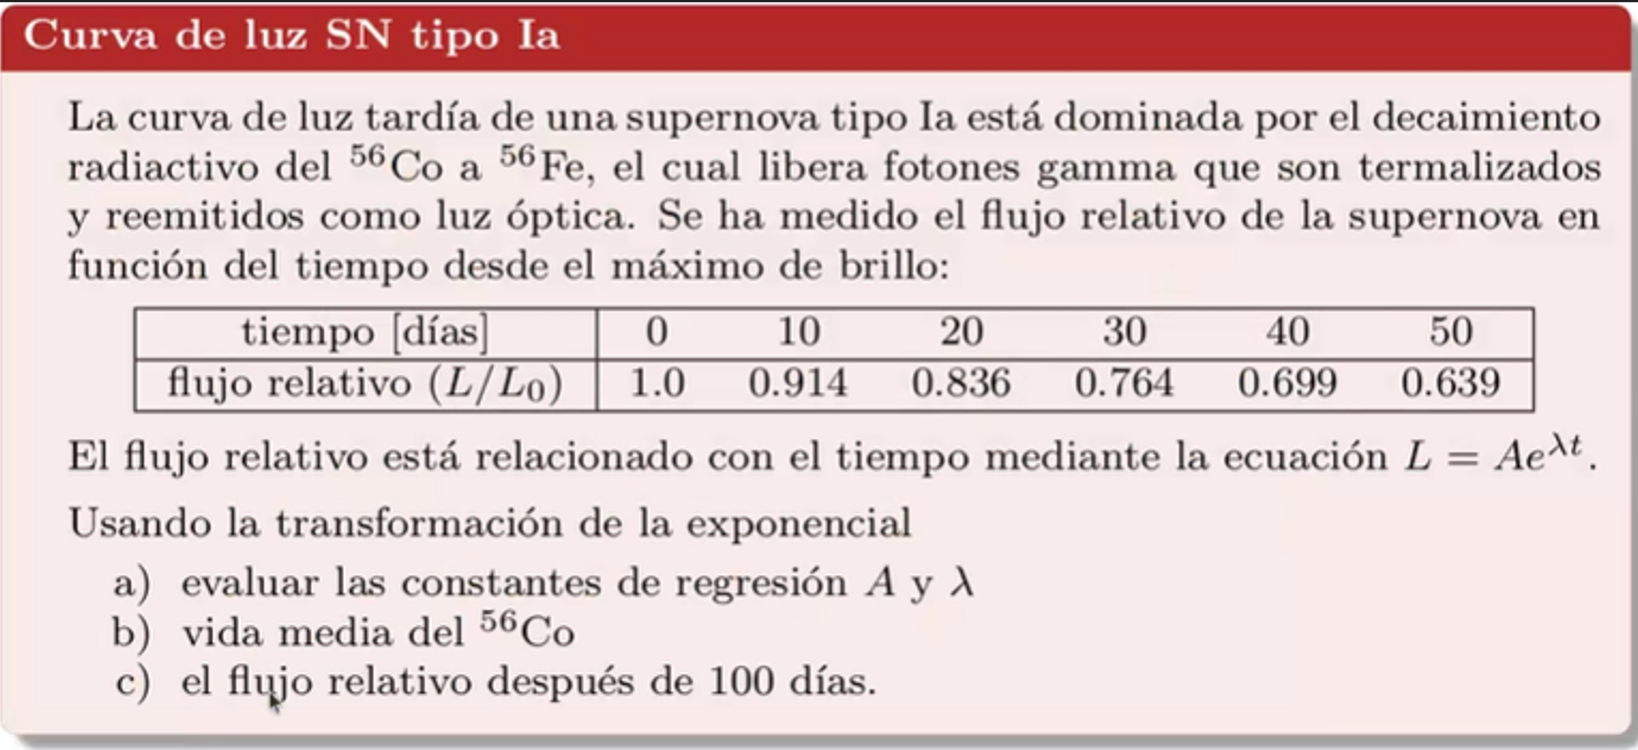

In [1]:
import numpy as np

# Datos observacionales de la curva de luz de la SN Ia
t0 = 0
t1 = 10
t2 = 20
t3 = 30
t4 = 40
t5 = 50

L0 = 1
L1 = 0.914
L2 = 0.836
L3 = 0.764
L4 = 0.699
L5 = 0.639

# Transformacion logaritmica del flujo relativo
y0 = np.log(L0)
y1 = np.log(L1)
y2 = np.log(L2)
y3 = np.log(L3)
y4 = np.log(L4)
y5 = np.log(L5)

# Numero total de puntos
n = 6.0

# Calculo del promedio de t y promedio de y
sum_t = t0 + t1 + t2 + t3 + t4 + t5
sum_y = y0 + y1 + y2 + y3 + y4 + y5

t_prom = sum_t / n
y_prom = sum_y / n

# Desviaciones respecto al promedio
dt0 = t0 - t_prom
dt1 = t1 - t_prom
dt2 = t2 - t_prom
dt3 = t3 - t_prom
dt4 = t4 - t_prom
dt5 = t5 - t_prom

dy0 = y0 - y_prom
dy1 = y1 - y_prom
dy2 = y2 - y_prom
dy3 = y3 - y_prom
dy4 = y4 - y_prom
dy5 = y5 - y_prom

# Metodo de Biseccion

lambda_a = -0.1
lambda_b = 0

tol = 1e-8
max_iter = 100
iteracion = 0

lambda_m = (lambda_a + lambda_b) / 2.0

while iteracion < max_iter:
    iteracion = iteracion + 1
    
    g_a = dt0*(dy0 - lambda_a*dt0) + dt1*(dy1 - lambda_a*dt1) + dt2*(dy2 - lambda_a*dt2) + dt3*(dy3 - lambda_a*dt3) + dt4*(dy4 - lambda_a*dt4) + dt5*(dy5 - lambda_a*dt5)
    
    lambda_m = (lambda_a + lambda_b) / 2.0
    g_m = dt0*(dy0 - lambda_m*dt0) + dt1*(dy1 - lambda_m*dt1) + dt2*(dy2 - lambda_m*dt2) + dt3*(dy3 - lambda_m*dt3) + dt4*(dy4 - lambda_m*dt4) + dt5*(dy5 - lambda_m*dt5)
    
    if abs(lambda_b - lambda_a) < tol:
        break
        
    if g_a * g_m < 0.0:
        lambda_b = lambda_m
    else:
        lambda_a = lambda_m

# Asignacion del valor optimo de lambda
lambda_opt = lambda_m

# a) a0 y de la constante A
a0 = y_prom - lambda_opt * t_prom
A_opt = np.exp(a0)

#b) Vida media del 56Co
vida_media = np.log(2.0) / (-lambda_opt)

# c) Flujo relativo a los 100 dias
t_eval = 100.0
L_100 = A_opt * np.exp(lambda_opt * t_eval)

# Impresion explícita de resultados
print("RESULTADOS DEL AJUSTE POR BISECCION")
print("a) Constantes de regresion:")
print("   A =", A_opt)
print("   lambda =", lambda_opt, "dias^-1")
print("b) Vida media del 56Co:")
print("   t_1/2 =", vida_media, "dias")
print("c) Flujo relativo despues de 100 dias:")
print("   L(100) =", L_100)

RESULTADOS DEL AJUSTE POR BISECCION
a) Constantes de regresion:
   A = 0.9998144545259344
   lambda = -0.008953872323036193 dias^-1
b) Vida media del 56Co:
   t_1/2 = 77.41311865444426 dias
c) Flujo relativo despues de 100 dias:
   L(100) = 0.40837361727216726
